Median Age of Death By Neighborhood
---------------
_____

The median age of death clearly demonstrates how healthy a neighborhood is, so it is an important factor to consider (maybe even the most important) when deciding on the healthiest neighborhood.

Setting Up the Data
----
___

First, let's import the libraries we need.

In [85]:
import pandas as pd
import matplotlib.pyplot as plt

Now, let's check out our data and make sure everything is in order.

In [86]:
data = pd.read_csv("FINAL/median_death_neighborhoods.csv")
data.head(10)

,_id,NEIGHBORHOOD,BLACKdeaths,Black MD AGE AT DEATH,WHITEdeaths,White MD AGE AT DEATH,TOTALdeaths*,TOTAL MD AGE AT DEATH
0,1,SOUTH SHORE,0.0,0.0,0.0,0.0,0.0,0.0
1,2,CHATEAU,0.0,0.0,2.0,NaN,2.0,NaN
2,3,NORTH SHORE,0.0,0.0,4.0,NaN,5.0,80.0
3,4,ALLEGHENY WEST,3.0,NaN,4.0,NaN,8.0,65.0
4,5,SAINT CLAIR,5.0,67.5,5.0,67.5,10.0,67.5
5,6,WEST END,5.0,76.7,9.0,78.0,14.0,77.5
6,7,ESPLEN,3.0,NaN,13.0,72.5,16.0,71.7
7,8,ARLINGTON HEIGHTS,10.0,55.0,7.0,72.5,17.0,63.7
8,9,STRIP DISTRICT,7.0,76.7,12.0,70.0,19.0,72.5
9,10,FAIRYWOOD,11.0,62.5,9.0,42.5,21.0,53.3


Now, the neighborhoods with less than 20 recorded deaths probably won't give us a very accurate estimate. Let's eliminate these from our data.

In [87]:
data = data[data["TOTALdeaths*"] > 20]
data.head(10)

,_id,NEIGHBORHOOD,BLACKdeaths,Black MD AGE AT DEATH,WHITEdeaths,White MD AGE AT DEATH,TOTALdeaths*,TOTAL MD AGE AT DEATH
9,10,FAIRYWOOD,11.0,62.5,9.0,42.5,21.0,53.3
10,11,HAYS,1.0,NaN,23.0,78.9,24.0,78.3
11,12,MOUNT OLIVER NEIGHBORHOOD,9.0,67.5,17.0,80.0,26.0,75.0
12,13,EAST CARNEGIE,9.0,72.5,18.0,81.0,27.0,80.0
13,14,REGENT SQUARE,1.0,NaN,27.0,75.8,28.0,76.7
14,15,CALIFORNIA-KIRKBRIDE,16.0,70.0,10.0,70.0,30.0,69.3
15,16,CHARTIERS CITY,20.0,70.0,15.0,81.2,35.0,76.9
16,17,FRIENDSHIP,15.0,66.2,24.0,73.0,41.0,71.1
17,18,BLUFF,18.0,71.7,24.0,69.0,42.0,70.0
18,19,ALLEGHENY CENTER,21.0,63.3,23.0,86.2,46.0,81.7


This looks better. Now we only include the neighborhoods where we have enough data to make a reasonable estimate.

Analyzing the Data
-----
___

Let's get the 10 neighborhoods with the highest median age of death, and then put them into a cleaner dataframe.

In [88]:
sorted_data = data.sort_values(by="TOTAL MD AGE AT DEATH", ascending=False)
sorted_data = sorted_data[["NEIGHBORHOOD", "TOTAL MD AGE AT DEATH"]]
sorted_data.head(10)

,NEIGHBORHOOD,TOTAL MD AGE AT DEATH
89,SQUIRREL HILL SOUTH,85.9
76,NORTH OAKLAND,85.6
71,BANKSVILLE,85.5
53,POINT BREEZE,85.1
68,SQUIRREL HILL NORTH,85.0
20,CENTRAL OAKLAND,84.0
28,NEW HOMESTEAD,83.4
27,SWISSHELM PARK,83.1
77,OVERBROOK,82.2
83,SHADYSIDE,82.1


That was simple! We now have our top 10 neighborhoods in terms of median age of death.
But, since that was so simple, I feel like we should do some more analysis.
So let's see *how* much better they are than average.

In [89]:
ave = sorted_data["TOTAL MD AGE AT DEATH"].mean()
sorted_data["DIFFERENCE FROM AVERAGE"] = sorted_data["TOTAL MD AGE AT DEATH"] - ave
sorted_data.head(10)

,NEIGHBORHOOD,TOTAL MD AGE AT DEATH,DIFFERENCE FROM AVERAGE
89,SQUIRREL HILL SOUTH,85.9,9.806173
76,NORTH OAKLAND,85.6,9.506173
71,BANKSVILLE,85.5,9.406173
53,POINT BREEZE,85.1,9.006173
68,SQUIRREL HILL NORTH,85.0,8.906173
20,CENTRAL OAKLAND,84.0,7.906173
28,NEW HOMESTEAD,83.4,7.306173
27,SWISSHELM PARK,83.1,7.006173
77,OVERBROOK,82.2,6.106173
83,SHADYSIDE,82.1,6.006173


9.8 years is a significant difference! Imagine where you were in the last 10 years, and how much you've grown since then, and how much more you could grow with an extra 10 years... maybe we should all move to Squirrel Hill South... we're getting too philosophical. The difference isn't mind-blowing, but it is quite significant.

Something Extra
-----
____

Since this dataset came with racial data, I decided to investigate whether there are racial disparities, and if so, how significant they are.

In [90]:
racial_data = data
racial_data["DIFFERENCE BY RACE"] = racial_data["White MD AGE AT DEATH"] - racial_data["Black MD AGE AT DEATH"]
racial_data = racial_data[racial_data["DIFFERENCE BY RACE"] == racial_data["DIFFERENCE BY RACE"]] # removing NaN values

racial_data = racial_data[racial_data["Black MD AGE AT DEATH"] != 0] # otherwise we get extremely high values (70+) which are misleading.
racial_data = racial_data[racial_data["White MD AGE AT DEATH"] != 0]

racial_data = racial_data.sort_values(by="DIFFERENCE BY RACE", ascending=False)
racial_data.head(10)


,_id,NEIGHBORHOOD,BLACKdeaths,Black MD AGE AT DEATH,WHITEdeaths,White MD AGE AT DEATH,TOTALdeaths*,TOTAL MD AGE AT DEATH,DIFFERENCE BY RACE
48,49,TROY HILL/HERR'S ISLAND,15.0,42.5,134.0,73.8,151.0,70.3,31.3
39,40,UPPER LAWRENCEVILLE,8.0,48.3,111.0,75.5,119.0,73.7,27.2
57,58,CRAFTON HEIGHTS,27.0,51.2,159.0,76.0,187.0,73.5,24.8
84,85,BEECHVIEW,35.0,55.8,398.0,80.2,434.0,78.9,24.4
18,19,ALLEGHENY CENTER,21.0,63.3,23.0,86.2,46.0,81.7,22.9
34,35,ARLINGTON,14.0,55.0,81.0,76.1,96.0,73.7,21.1
51,52,WESTWOOD,12.0,58.3,159.0,77.8,173.0,77.0,19.5
67,68,SOUTHSIDE SLOPES,9.0,58.7,208.0,77.9,220.0,77.2,19.2
53,54,POINT BREEZE,13.0,66.7,158.0,85.7,175.0,85.1,19.0
87,88,CARRICK,35.0,59.4,622.0,77.0,678.0,75.9,17.6


There are some pretty huge differences here. These are even more significant than the differences between neighborhoods. Let's get these on a plot.

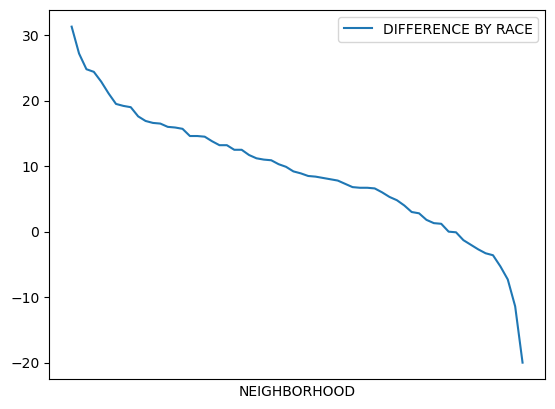

In [91]:
racial_data.plot(x='NEIGHBORHOOD', y='DIFFERENCE BY RACE')
plt.xticks([])
plt.show()

For a vast majority of the neighborhoods (looks to be over 80%), white people live longer than Black people. And for about 50% of neighborhoods, the difference is over 10 years; this is quite shocking. How about we actually calculate these percentages instead of eyeballing it?

In [92]:
count = len(racial_data[racial_data['DIFFERENCE BY RACE'] > 0])
perc = count / len(racial_data) * 100
perc = round(perc, 2)
print("Percent of neighborhoods where white people live longer than Black people: " + str(perc))
count2 = len(racial_data[racial_data['DIFFERENCE BY RACE'] > 10])
med = racial_data['DIFFERENCE BY RACE'].median()
med = round(med, 2)
print("In half of all neighborhoods, this difference is over " + str(med) + " YEARS.")

Percent of neighborhoods where white people live longer than Black people: 82.26
In half of all neighborhoods, this difference is over 9.05 YEARS.


Key Findings (Conclusion)
-
______________

The 10 neighborhoods with the highest median age of death, as well as how much above average they are, are shown below:

In [93]:
sorted_data.head(10)

,NEIGHBORHOOD,TOTAL MD AGE AT DEATH,DIFFERENCE FROM AVERAGE
89,SQUIRREL HILL SOUTH,85.9,9.806173
76,NORTH OAKLAND,85.6,9.506173
71,BANKSVILLE,85.5,9.406173
53,POINT BREEZE,85.1,9.006173
68,SQUIRREL HILL NORTH,85.0,8.906173
20,CENTRAL OAKLAND,84.0,7.906173
28,NEW HOMESTEAD,83.4,7.306173
27,SWISSHELM PARK,83.1,7.006173
77,OVERBROOK,82.2,6.106173
83,SHADYSIDE,82.1,6.006173


**Written Conclusion**
___
There is not too much to say about this, as most of it is self-evident, but I will come up with something. Squirrel Hill South has a median age of death almost 10 years above average, which is massive. As we move down the list, the difference becomes less extreme, but even 6 extra years of life is significant. Squirrel Hill and Oakland both show up twice on this list, so I guess they are super cool and healthy. One interesting thing I noticed is that half of the neighborhoods on this list are within 2 miles of the Cathedral of Learning. Are the people of these neighborhoods so inspired by Cathy's presence that they want to live longer? Or is something more sinister in the works? Are they stealing Cathy's lifeforce, causing her to sink into the ground? We will not speculate here.
___
Not for the project but simply out of curiosity, I decided to also analyze the racial data that was provided in the dataset. For some reason, they only included specific data on white and Black people, so that was all I analyzed. I found that in over 82% of neighborhoods, white people tend to live longer than Black people. Additionally, I found that in 50% of neighborhoods, white people tend to live at least *9 YEARS LONGER* than Black people -- a huge difference. Given such a huge difference for the majority of neighborhoods, this is definitely not a coincidence. Perhaps with more datasets, someone could discover the causes of this problem. But with what I have, I can only see the effects, which are quite shocking.